# 🛡️ Web Attack Risk Prediction & Cost-Benefit Analysis

## Proje Özeti
Bu projede, web uygulamalarına yönelik siber saldırıların tespiti için makine öğrenmesi modelleri geliştirilmiş, modelin iş değeri KVKK mevzuatı ve gerçek dünya maliyet verileriyle kanıtlanmıştır.

### Veri Kaynakları (4 Farklı Kaynak)
| # | Kaynak | Tür | Açıklama |
|---|--------|-----|----------|
| 1 | CSIC 2010 HTTP Dataset | Kaggle CSV | 61.000+ normal ve anomalous HTTP request |
| 2 | Web Application Payloads | Kaggle JSONL | SQLi, XSS, SSRF, RCE payload koleksiyonu |
| 3 | Foospidy Payloads | GitHub | Gerçek dünya saldırı imzaları (4 kategori) |
| 4 | Türkiye Siber Olay & KVKK Veritabanı | Sentetik | 250 siber olay, KVKK cezaları, maliyet verileri |

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import os
import math
import warnings
from urllib.parse import unquote, urlparse
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, roc_auc_score, precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')

# Görselleştirme ayarları
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.figsize': (12, 6)
})

RANDOM_STATE = 42
print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


---
## 1. Veri Yükleme ve İlk Keşif

### 1.1 Kaynak 1: CSIC 2010 HTTP Dataset
İspanya Ulusal Araştırma Konseyi tarafından bir e-ticaret uygulamasında üretilmiş HTTP trafiği. Normal ve saldırı içeren request'leri barındırır.

In [2]:
# ============================================================
# KAYNAK 1: CSIC 2010 HTTP Dataset
# ============================================================
df_csic = pd.read_csv('../data/raw/csic_database.csv')

print("=" * 60)
print("KAYNAK 1: CSIC 2010 HTTP Dataset")
print("=" * 60)
print(f"Boyut: {df_csic.shape}")
print(f"\nSütunlar: {list(df_csic.columns)}")
print(f"\nLabel dağılımı:")
print(df_csic['classification'].value_counts() if 'classification' in df_csic.columns
      else df_csic.iloc[:, -1].value_counts())
print(f"\nİlk 3 satır:")
df_csic.head(3)

KAYNAK 1: CSIC 2010 HTTP Dataset
Boyut: (61065, 17)

Sütunlar: ['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie', 'content-type', 'connection', 'lenght', 'content', 'classification', 'URL']

Label dağılımı:
classification
0    36000
1    25065
Name: count, dtype: int64

İlk 3 satır:


,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.j...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&...,0,http://localhost:8080/tienda1/publico/anadir.j...


### 1.2 Kaynak 2: Web Application Payloads (Kaggle)
SQLi, XSS, SSRF, RCE gibi saldırı payload'larını içeren koleksiyon.

In [3]:
# ============================================================
# KAYNAK 2: Web Application Payloads (JSON - tolerant parsing)
# ============================================================
with open('../data/raw/WEB_APPLICATION_PAYLOADS.jsonl', 'r', encoding='utf-8', errors='ignore') as f:
    content = f.read()

# Her JSON objesini ayrı ayrı bul
import re
pattern = r'\{[^{}]+\}'
matches = re.findall(pattern, content)

payloads_kaggle = []
for m in matches:
    try:
        obj = json.loads(m)
        payloads_kaggle.append(obj)
    except:
        continue

df_payloads_kaggle = pd.DataFrame(payloads_kaggle)

print("=" * 60)
print("KAYNAK 2: Web Application Payloads")
print("=" * 60)
print(f"Boyut: {df_payloads_kaggle.shape}")
print(f"Sütunlar: {list(df_payloads_kaggle.columns)}")
if len(df_payloads_kaggle) > 0:
    print(f"\nİlk 3 satır:")
    display(df_payloads_kaggle.head(3))

KAYNAK 2: Web Application Payloads
Boyut: (455, 8)
Sütunlar: ['id', 'description', 'payload', 'context', 'type', 'severity', 'example_query', 'example_usage']

İlk 3 satır:


,id,description,payload,context,type,severity,example_query,example_usage
0,sqli-001,Basic tautology-based SQL injection,' OR '1'='1,Login form username input,tautology,high,SELECT * FROM users WHERE username = '' OR '1'...,NaN
1,sqli-002,Union-based SQL injection to extract data,"' UNION SELECT username, password FROM users--",Search input field,union,high,"SELECT name, description FROM products WHERE n...",NaN
2,sqli-003,Blind SQL injection with time delay,'; WAITFOR DELAY '0:0:5'--,ID parameter in URL,blind-time,medium,SELECT * FROM orders WHERE id = ''; WAITFOR DE...,NaN


### 1.3 Kaynak 3: Foospidy Payload Koleksiyonları (GitHub)
Gerçek dünya saldırı imzalarını içeren açık kaynak payload koleksiyonu.

In [4]:
# ============================================================
# KAYNAK 3: Foospidy Payloads (GitHub)
# ============================================================
def load_payloads(folder_path, attack_type):
    payloads = []
    if not os.path.exists(folder_path):
        return payloads
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            filepath = os.path.join(folder_path, filename)
            with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith('#'):
                        payloads.append({'payload': line, 'attack_type': attack_type})
    return payloads

base = '../data/raw/other'
sqli = load_payloads(f'{base}/sqli', 'sqli')
xss = load_payloads(f'{base}/xss', 'xss')
rce = load_payloads(f'{base}/commandinjection', 'rce')
traversal = load_payloads(f'{base}/traversal', 'path_traversal')
df_payloads_foospidy = pd.DataFrame(sqli + xss + rce + traversal)

print("=" * 60)
print("KAYNAK 3: Foospidy Payloads")
print("=" * 60)
print(f"Toplam payload: {len(df_payloads_foospidy)}")
print(f"\nSaldırı türü dağılımı:")
print(df_payloads_foospidy['attack_type'].value_counts())

KAYNAK 3: Foospidy Payloads
Toplam payload: 28569

Saldırı türü dağılımı:
attack_type
path_traversal    21144
xss                6253
sqli                654
rce                 518
Name: count, dtype: int64


### 1.4 Kaynak 4: Türkiye Siber Olay & KVKK Veritabanı
KVKK cezaları, şirket büyüklüğü, sektör, müşteri kaybı ve toplam olay maliyetini içeren sentetik veritabanı.

In [5]:
# ============================================================
# KAYNAK 4: Türkiye Siber Olay & KVKK Veritabanı
# ============================================================
df_kvkk = pd.read_csv('../data/raw/turkey_cyber_incidents.csv')

print("=" * 60)
print("KAYNAK 4: Türkiye Siber Olay & KVKK Veritabanı")
print("=" * 60)
print(f"Boyut: {df_kvkk.shape}")
print(f"\nSaldırı türü dağılımı:")
print(df_kvkk['attack_type'].value_counts())
print(f"\nOrtalama KVKK cezası: {df_kvkk['kvkk_fine_tl'].mean():,.0f} TL")
print(f"Maksimum KVKK cezası: {df_kvkk['kvkk_fine_tl'].max():,.0f} TL")
print(f"\nOrtalama toplam olay maliyeti: {df_kvkk['total_incident_cost_tl'].mean():,.0f} TL")

KAYNAK 4: Türkiye Siber Olay & KVKK Veritabanı
Boyut: (250, 18)

Saldırı türü dağılımı:
attack_type
xss               41
ransomware        33
path_traversal    32
ddos              30
sqli              30
brute_force       29
phishing          29
rce               26
Name: count, dtype: int64

Ortalama KVKK cezası: 2,920,197 TL
Maksimum KVKK cezası: 13,620,402 TL

Ortalama toplam olay maliyeti: 8,735,389 TL


---
## 2. Veri Harmanlama (Data Fusion)

### Strateji:
1. **Kaynak 2 + 3 birleştirilir** → Unified payload veritabanı oluşturulur
2. **Payload veritabanından regex pattern'leri üretilir** → CSIC request'lerine uygulanır
3. **KVKK veritabanından maliyet mapping'i çıkarılır** → Saldırı türüne göre merge edilir

Bu sayede 4 farklı kaynak anlamlı şekilde birleştirilmiş olur.

In [6]:
# ============================================================
# ADIM 1: Payload veritabanlarını birleştir (Kaynak 2 + 3)
# ============================================================

# Kaynak 2'den payload ve type bilgisi al
kaggle_payloads = df_payloads_kaggle[['payload', 'type', 'severity']].copy()
kaggle_payloads.columns = ['payload', 'attack_type', 'severity']

# attack_type'ı standartlaştır
type_mapping = {
    'tautology': 'sqli', 'union': 'sqli', 'piggy-backed': 'sqli',
    'blind-time': 'sqli', 'blind-boolean': 'sqli', 'error-based': 'sqli',
    'stored': 'xss', 'reflected': 'xss', 'dom': 'xss',
    'classic': 'rce', 'blind': 'rce',
    'basic': 'path_traversal', 'encoded': 'path_traversal', 'null-byte': 'path_traversal',
    'url': 'ssrf', 'cloud-metadata': 'ssrf'
}
kaggle_payloads['attack_type'] = kaggle_payloads['attack_type'].map(type_mapping).fillna('other')

# Kaynak 3 zaten standart formatta
# Birleştir
df_all_payloads = pd.concat([
    kaggle_payloads[['payload', 'attack_type']],
    df_payloads_foospidy[['payload', 'attack_type']]
], ignore_index=True)

print("=" * 60)
print("BİRLEŞİK PAYLOAD VERİTABANI")
print("=" * 60)
print(f"Toplam payload: {len(df_all_payloads)}")
print(f"\nSaldırı türü dağılımı:")
print(df_all_payloads['attack_type'].value_counts())

BİRLEŞİK PAYLOAD VERİTABANI
Toplam payload: 29024

Saldırı türü dağılımı:
attack_type
path_traversal    21144
xss                6347
sqli                728
rce                 518
other               287
Name: count, dtype: int64


In [7]:
# ============================================================
# ADIM 2: Payload'lardan regex pattern'leri üret → CSIC'e uygula
# ============================================================
sqli_regex = re.compile(
    r"(union\s+select|or\s+1\s*=\s*1|'\s*or\s*'|drop\s+table|insert\s+into|"
    r"select\s+.*\s+from|having\s+1\s*=\s*1|waitfor\s+delay|benchmark\s*\(|"
    r"sleep\s*\(|order\s+by\s+\d|information_schema|load_file|"
    r"concat\s*\(|char\s*\(|substring\s*\(|database\s*\(|@@version|"
    r"0x[0-9a-fA-F]+|--\s*$|/\*)", re.IGNORECASE)

xss_regex = re.compile(
    r"(<script|<img\s|<svg\s|<iframe\s|<object\s|<embed\s|"
    r"onerror\s*=|onload\s*=|onclick\s*=|onmouseover\s*=|onfocus\s*=|"
    r"javascript\s*:|alert\s*\(|prompt\s*\(|confirm\s*\(|document\.cookie|"
    r"document\.write|eval\s*\(|fromcharcode)", re.IGNORECASE)

rce_regex = re.compile(
    r"(;\s*cat\s|;\s*ls\s|;\s*id\s*$|;\s*whoami|;\s*pwd|;\s*uname|"
    r"\|\s*cat\s|\|\s*ls\s|`.*`|\$\(.*\)|/bin/sh|/bin/bash|"
    r"cmd\.exe|powershell|system\s*\(|exec\s*\(|passthru\s*\(|"
    r"shell_exec|wget\s|curl\s.*\|)", re.IGNORECASE)

traversal_regex = re.compile(
    r"(\.\./|\.\.\\|%2e%2e%2f|%2e%2e/|"
    r"/etc/passwd|/etc/shadow|/etc/hosts|"
    r"boot\.ini|win\.ini|web\.config|"
    r"c:\\windows|c:/windows)", re.IGNORECASE)

def detect_attack_type(row):
    """HTTP request'teki saldırı türünü payload pattern'leri ile tespit eder."""
    url = unquote(str(row.get('URL', '')))
    content = unquote(str(row.get('content', '')))
    text = url + ' ' + content

    if sqli_regex.search(text): return 'sqli'
    if xss_regex.search(text): return 'xss'
    if rce_regex.search(text): return 'rce'
    if traversal_regex.search(text): return 'path_traversal'
    if row.get('classification', 0) == 1: return 'other_attack'
    return 'none'

print("Saldırı türü tespiti başlıyor...")
df_csic['attack_type_detected'] = df_csic.apply(detect_attack_type, axis=1)

print("Tespit edilen saldırı türleri:")
print(df_csic['attack_type_detected'].value_counts())
print(f"\n{len(df_all_payloads)} payload'dan üretilen pattern'lerle eşleştirildi.")

Saldırı türü tespiti başlıyor...
Tespit edilen saldırı türleri:
attack_type_detected
none              36000
other_attack      23672
xss                 736
sqli                463
path_traversal      194
Name: count, dtype: int64

29024 payload'dan üretilen pattern'lerle eşleştirildi.


In [8]:
# ============================================================
# ADIM 3: KVKK maliyet verisinden saldırı türü bazlı mapping oluştur
# ============================================================
kvkk_cost_mapping = df_kvkk.groupby('attack_type').agg(
    avg_kvkk_fine=('kvkk_fine_tl', 'mean'),
    avg_total_cost=('total_incident_cost_tl', 'mean'),
    avg_churn_rate=('customer_churn_rate', 'mean'),
    avg_detection_time=('detection_time_hours', 'mean'),
    avg_downtime=('system_downtime_hours', 'mean'),
    avg_reputation_damage=('reputation_damage_score', 'mean'),
    ml_detection_rate=('attack_detected_by_ml', 'mean')
).round(2)

print("=" * 60)
print("KVKK MALİYET MAPPING (Saldırı Türü Bazlı)")
print("=" * 60)
display(kvkk_cost_mapping)

# CSIC verisine KVKK maliyet bilgisini merge et
df_merged = df_csic.merge(
    kvkk_cost_mapping,
    left_on='attack_type_detected',
    right_index=True,
    how='left'
)

# none ve other_attack için default değerler
df_merged['avg_kvkk_fine'] = df_merged['avg_kvkk_fine'].fillna(0)
df_merged['avg_total_cost'] = df_merged['avg_total_cost'].fillna(0)
df_merged['avg_churn_rate'] = df_merged['avg_churn_rate'].fillna(0)
df_merged['avg_detection_time'] = df_merged['avg_detection_time'].fillna(0)
df_merged['avg_downtime'] = df_merged['avg_downtime'].fillna(0)
df_merged['avg_reputation_damage'] = df_merged['avg_reputation_damage'].fillna(0)
df_merged['ml_detection_rate'] = df_merged['ml_detection_rate'].fillna(0)

print(f"\n✅ VERİ HARMANLAMA TAMAMLANDI")
print(f"Kaynak 1 (CSIC): {len(df_csic)} request")
print(f"Kaynak 2+3 (Payloads): {len(df_all_payloads)} payload → regex pattern")
print(f"Kaynak 4 (KVKK): {len(df_kvkk)} olay → maliyet mapping")
print(f"Birleştirilmiş dataset: {df_merged.shape}")

KVKK MALİYET MAPPING (Saldırı Türü Bazlı)


,avg_kvkk_fine,avg_total_cost,avg_churn_rate,avg_detection_time,avg_downtime,avg_reputation_damage,ml_detection_rate
attack_type,,,,,,,
brute_force,3616884.62,9810881.41,0.10,151.63,163.64,5.93,0.45
ddos,1545516.73,6285792.50,0.08,167.56,67.71,4.27,0.60
path_traversal,3131353.12,9249774.69,0.12,231.74,154.03,6.03,0.41
phishing,3192196.38,8773857.34,0.11,153.91,138.99,5.17,0.59
ransomware,2018126.61,7599850.24,0.09,170.54,104.89,4.64,0.48
rce,3532964.50,8958003.35,0.11,226.51,122.17,5.58,0.38
sqli,3949031.03,11860846.87,0.11,255.89,195.59,6.47,0.43
xss,2660755.00,7824258.73,0.11,188.15,106.67,5.17,0.41



✅ VERİ HARMANLAMA TAMAMLANDI
Kaynak 1 (CSIC): 61065 request
Kaynak 2+3 (Payloads): 29024 payload → regex pattern
Kaynak 4 (KVKK): 250 olay → maliyet mapping
Birleştirilmiş dataset: (61065, 25)


---
## 3. İş Mantığına Dayalı Feature Engineering

HTTP request'lerden siber güvenlik domain bilgisine dayalı 10 yeni feature türetilmiştir. Regex-based pattern flag'leri modelden çıkarılmıştır (data leakage önlemi).

In [9]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
def calculate_entropy(text):
    """Shannon entropy — obfuscated payload'lar yüksek entropi gösterir."""
    if not text or len(text) == 0: return 0.0
    counts = Counter(text)
    length = len(text)
    return -sum((c/length) * math.log2(c/length) for c in counts.values() if c > 0)

def extract_features(row):
    """HTTP request'ten iş mantığına dayalı feature'lar çıkarır."""
    url = str(row.get('URL', ''))
    content = str(row.get('content', ''))
    method = str(row.get('Method', ''))
    full = url + ' ' + content
    decoded = unquote(full)

    special = set("'\";<>(){}[]|&$`!@#%^*~\\")
    parsed = urlparse(url)

    return pd.Series({
        # Temel request özellikleri
        'request_length': len(full),
        'url_length': len(url),
        'content_length': len(content),

        # Saldırı göstergeleri
        'special_char_count': sum(1 for c in decoded if c in special),
        'digit_count': sum(1 for c in decoded if c.isdigit()),
        'uppercase_ratio': sum(1 for c in decoded if c.isupper()) / max(len(decoded), 1),

        # Yapısal özellikler
        'parameter_count': url.count('&') + (1 if '?' in url else 0) + content.count('&') + (1 if content and '=' in content else 0),
        'url_depth': parsed.path.count('/') if parsed.path else 0,

        # Gelişmiş güvenlik metrikleri
        'entropy_score': round(calculate_entropy(decoded), 4),
        'encoded_char_ratio': round(len(re.findall(r'%[0-9a-fA-F]{2}', full)) / max(len(full), 1), 4),

        # Request tipi
        'is_post': 1 if method == 'POST' else 0,
        'is_put': 1 if method == 'PUT' else 0,
    })

print("Feature extraction başlıyor (bu 1-2 dakika sürebilir)...")
features = df_merged.apply(extract_features, axis=1)
df_final = pd.concat([df_merged, features], axis=1)

# KVKK bazlı türetilmiş feature
df_final['estimated_incident_cost'] = df_final['avg_total_cost'] * (df_final['classification'])

print(f"✅ Feature engineering tamamlandı!")
print(f"Toplam feature sayısı: {len(features.columns)} yeni + KVKK bazlı")
print(f"Dataset boyutu: {df_final.shape}")
print(f"\nTüretilen feature'lar:")
for col in features.columns:
    print(f"  • {col}")

Feature extraction başlıyor (bu 1-2 dakika sürebilir)...
✅ Feature engineering tamamlandı!
Toplam feature sayısı: 12 yeni + KVKK bazlı
Dataset boyutu: (61065, 38)

Türetilen feature'lar:
  • request_length
  • url_length
  • content_length
  • special_char_count
  • digit_count
  • uppercase_ratio
  • parameter_count
  • url_depth
  • entropy_score
  • encoded_char_ratio
  • is_post
  • is_put


---
## 4. Keşifçi Veri Analizi (EDA)

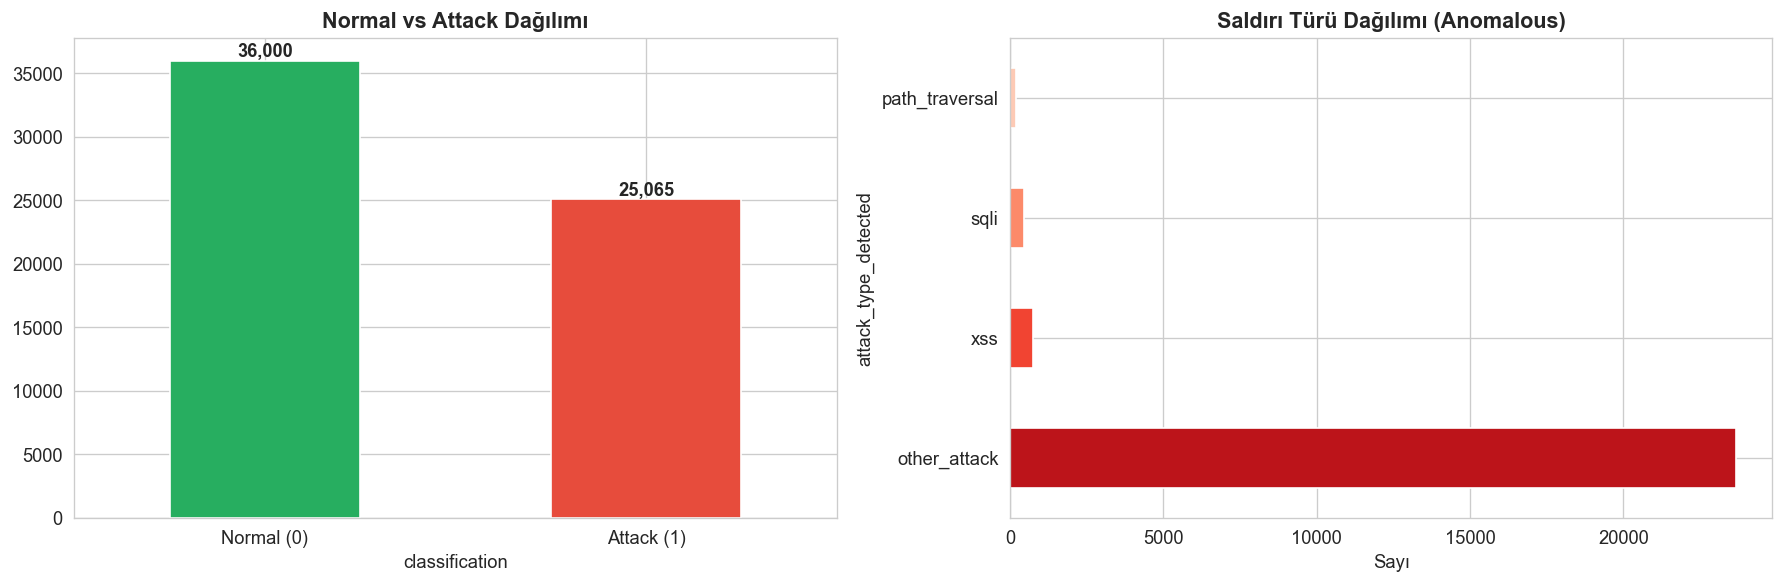

In [10]:
# EDA 1: Sınıf Dağılımı ve Saldırı Türleri
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_class = ['#27ae60', '#e74c3c']
df_final['classification'].value_counts().plot(kind='bar', ax=axes[0], color=colors_class)
axes[0].set_title('Normal vs Attack Dağılımı', fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'], rotation=0)
for i, v in enumerate(df_final['classification'].value_counts().sort_index()):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

attack_df = df_final[df_final['classification'] == 1]
attack_counts = attack_df['attack_type_detected'].value_counts()
colors_attack = sns.color_palette('Reds_r', len(attack_counts))
attack_counts.plot(kind='barh', ax=axes[1], color=colors_attack)
axes[1].set_title('Saldırı Türü Dağılımı (Anomalous)', fontweight='bold')
axes[1].set_xlabel('Sayı')

plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

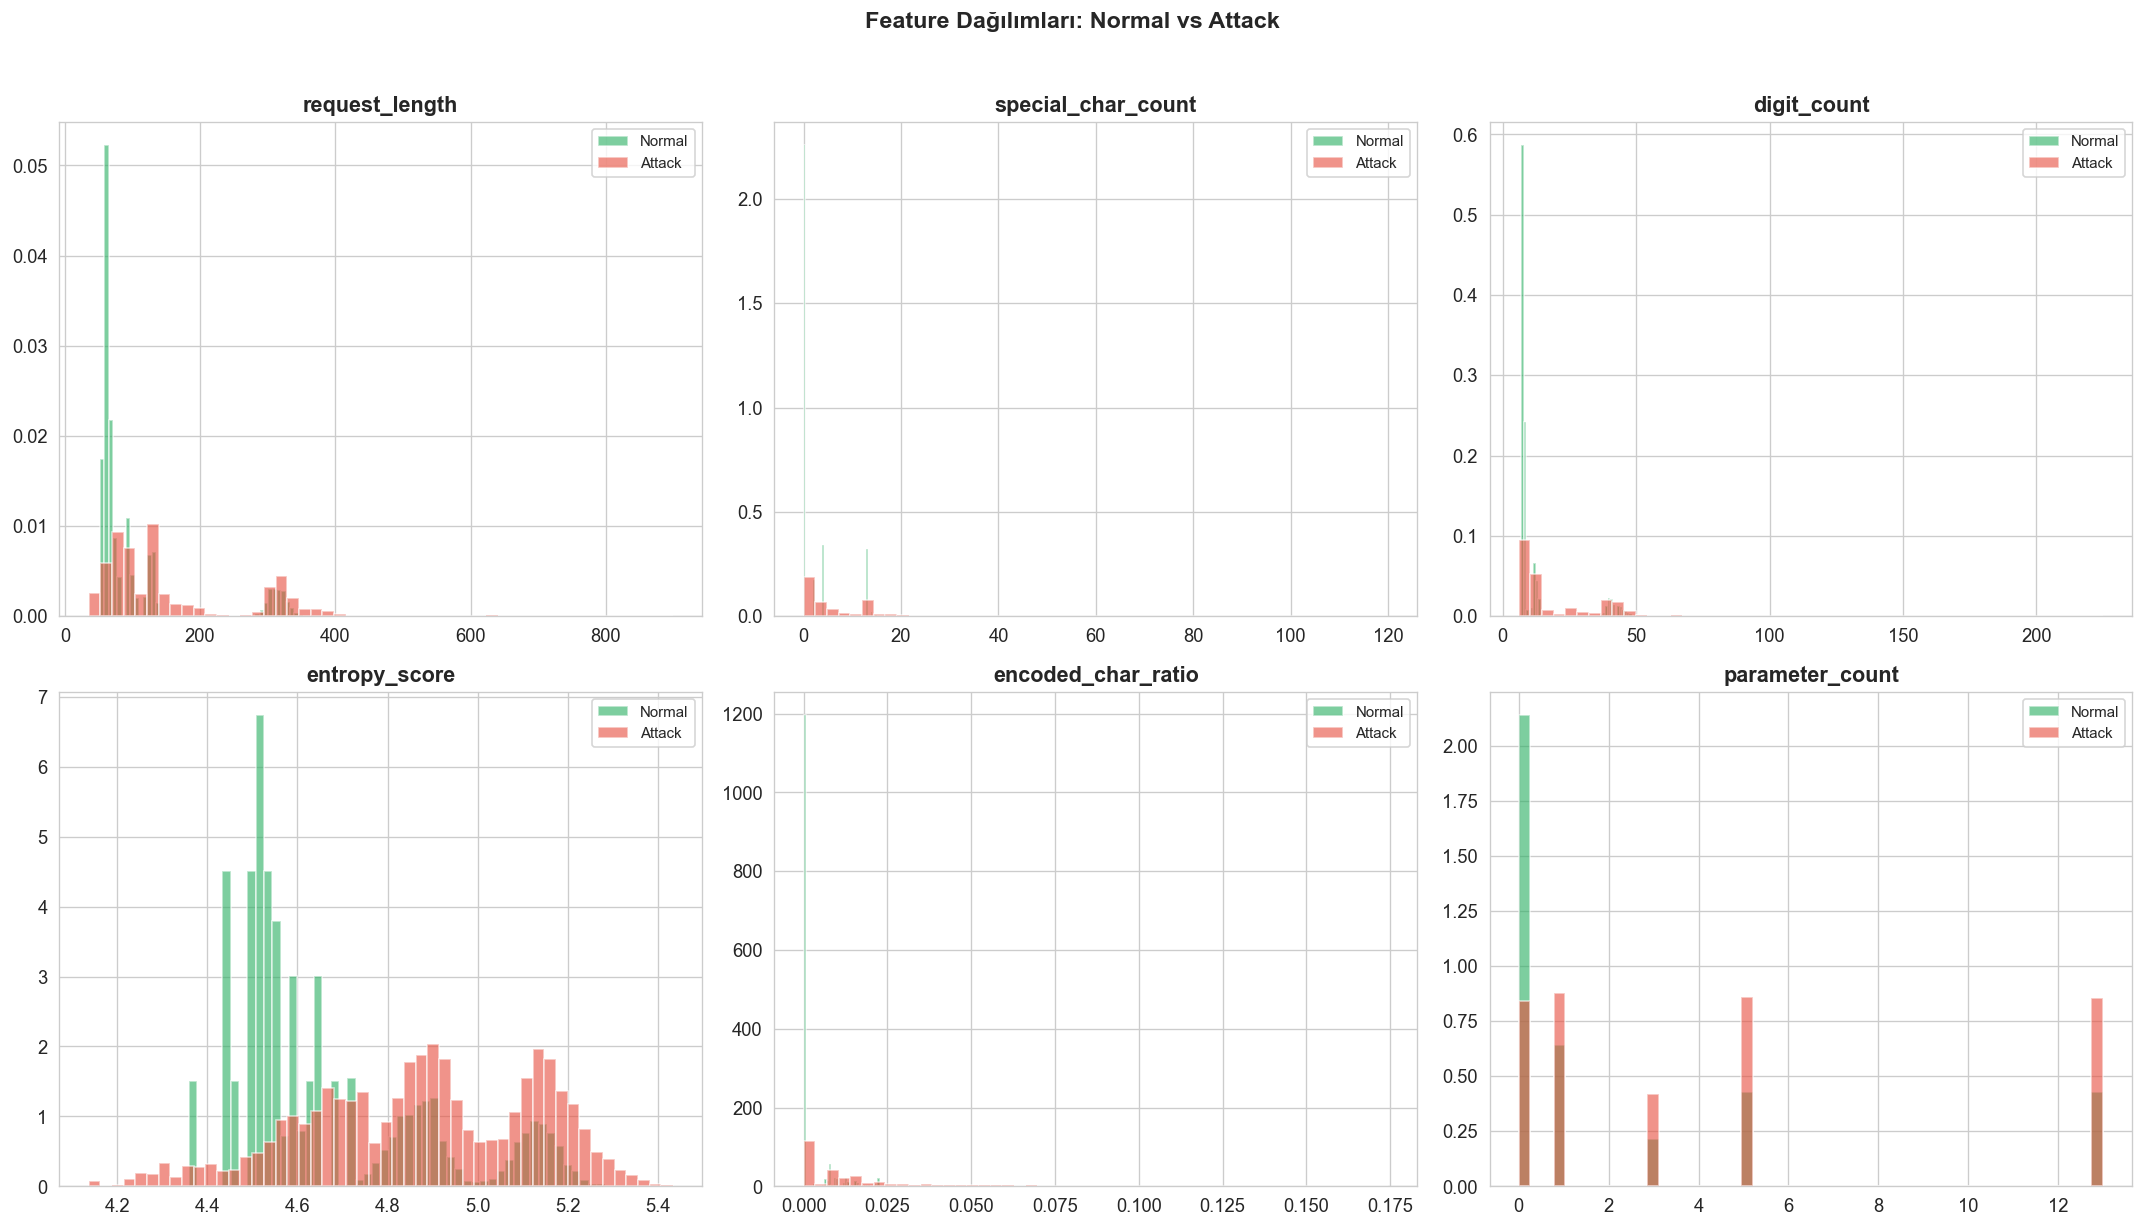

In [11]:
# EDA 2: Feature Dağılımları — Normal vs Attack
numeric_feats = ['request_length', 'special_char_count', 'digit_count',
                 'entropy_score', 'encoded_char_ratio', 'parameter_count']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(numeric_feats):
    normal = df_final[df_final['classification'] == 0][feat]
    attack = df_final[df_final['classification'] == 1][feat]
    axes[i].hist(normal, bins=50, alpha=0.6, label='Normal', color='#27ae60', density=True)
    axes[i].hist(attack, bins=50, alpha=0.6, label='Attack', color='#e74c3c', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Dağılımları: Normal vs Attack', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

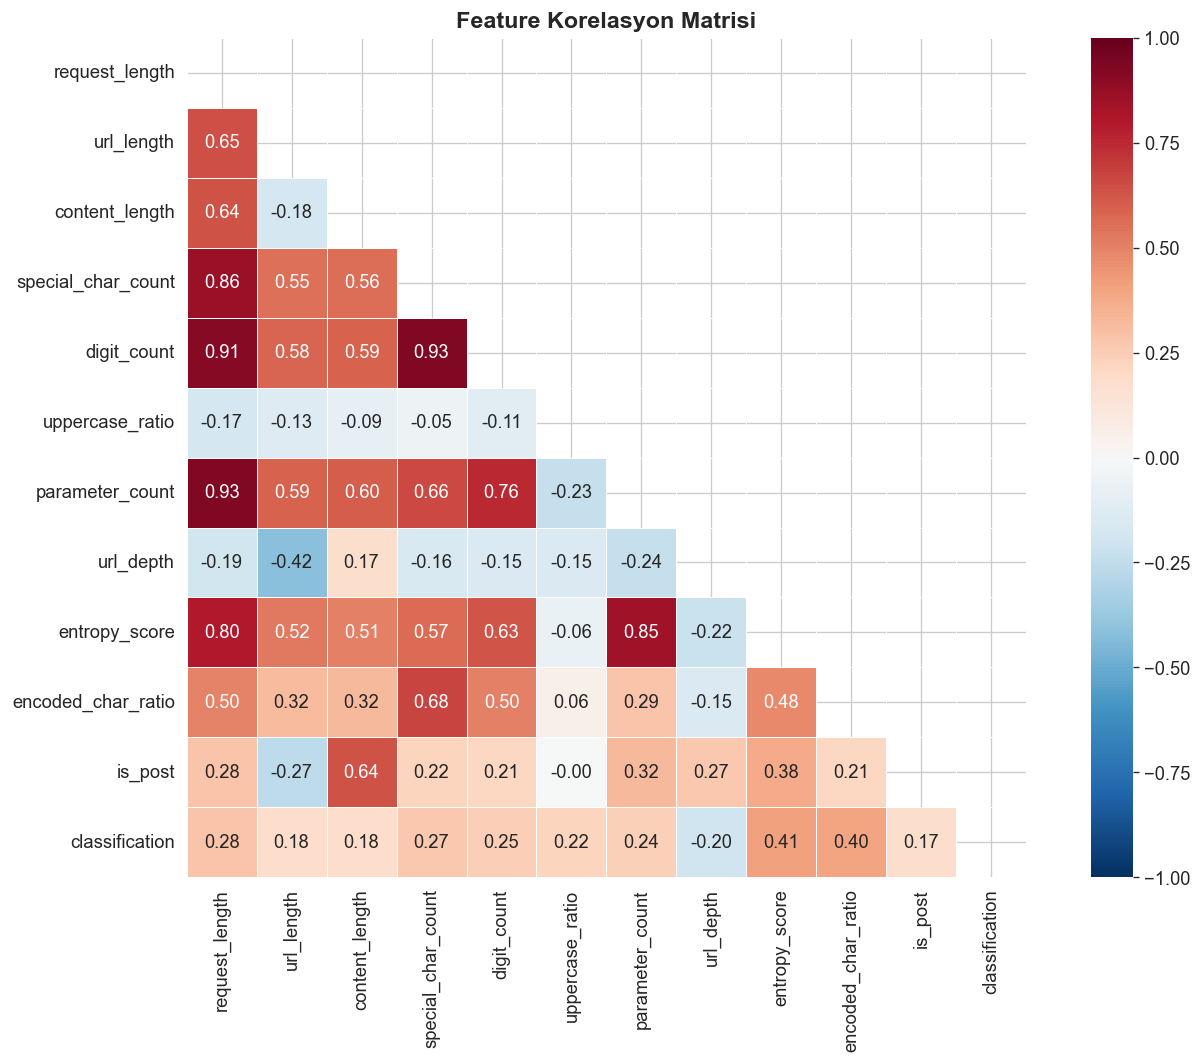

In [12]:
# EDA 3: Korelasyon Matrisi
feature_cols = ['request_length', 'url_length', 'content_length', 'special_char_count',
                'digit_count', 'uppercase_ratio', 'parameter_count', 'url_depth',
                'entropy_score', 'encoded_char_ratio', 'is_post', 'classification']

corr = df_final[feature_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Korelasyon Matrisi', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

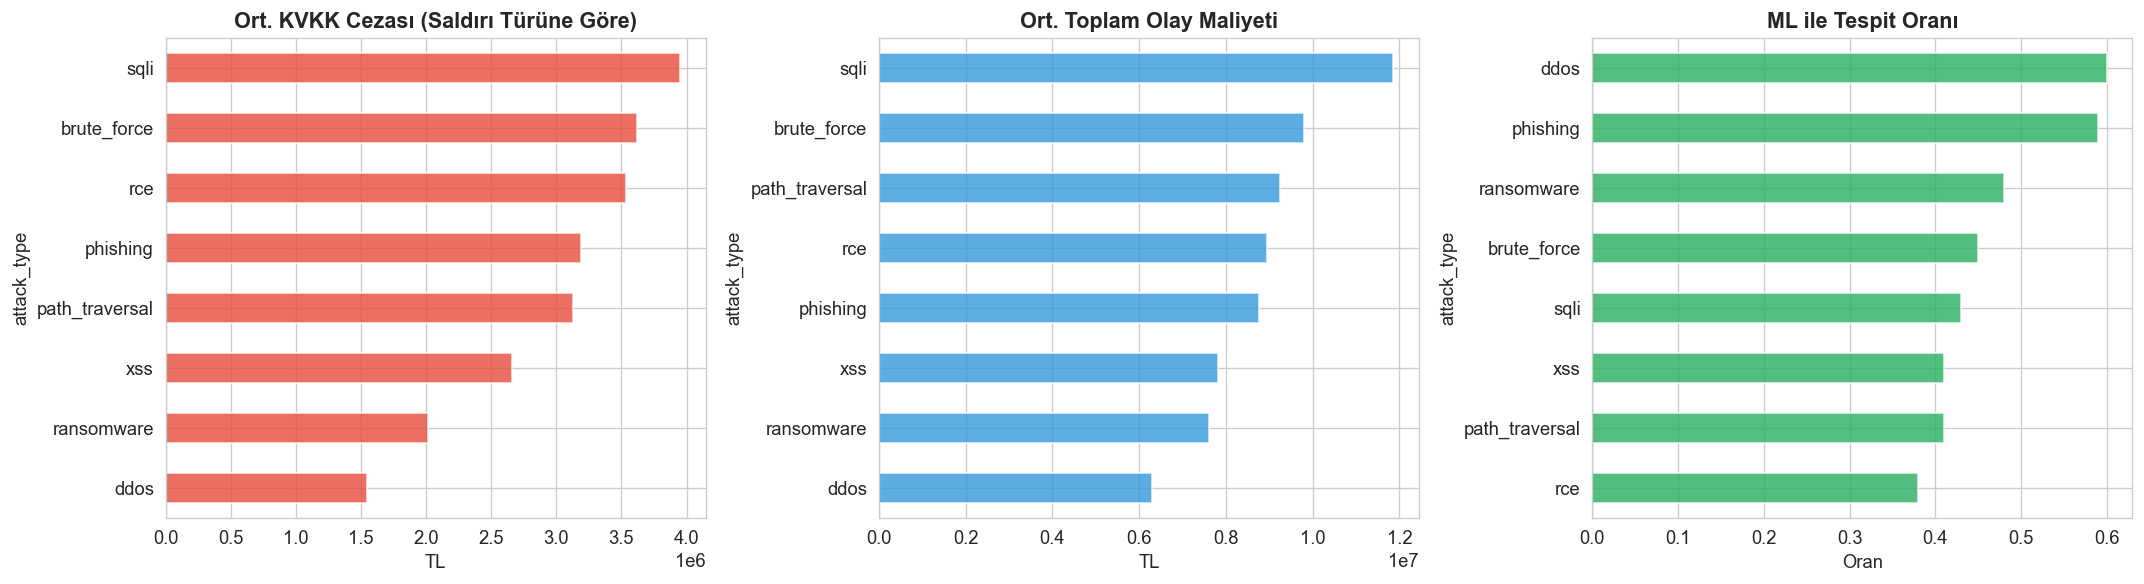

💰 En pahalı saldırı türü: sqli (11,860,847 TL)


In [13]:
# EDA 4: KVKK Maliyet Analizi (Kaynak 4)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Saldırı türüne göre ortalama KVKK cezası
kvkk_cost_mapping['avg_kvkk_fine'].sort_values().plot(kind='barh', ax=axes[0], color='#e74c3c', alpha=0.8)
axes[0].set_title('Ort. KVKK Cezası (Saldırı Türüne Göre)', fontweight='bold')
axes[0].set_xlabel('TL')

# Saldırı türüne göre ortalama toplam maliyet
kvkk_cost_mapping['avg_total_cost'].sort_values().plot(kind='barh', ax=axes[1], color='#3498db', alpha=0.8)
axes[1].set_title('Ort. Toplam Olay Maliyeti', fontweight='bold')
axes[1].set_xlabel('TL')

# ML tespit oranı
kvkk_cost_mapping['ml_detection_rate'].sort_values().plot(kind='barh', ax=axes[2], color='#27ae60', alpha=0.8)
axes[2].set_title('ML ile Tespit Oranı', fontweight='bold')
axes[2].set_xlabel('Oran')

plt.tight_layout()
plt.savefig('../outputs/figures/kvkk_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💰 En pahalı saldırı türü: {kvkk_cost_mapping['avg_total_cost'].idxmax()} "
      f"({kvkk_cost_mapping['avg_total_cost'].max():,.0f} TL)")

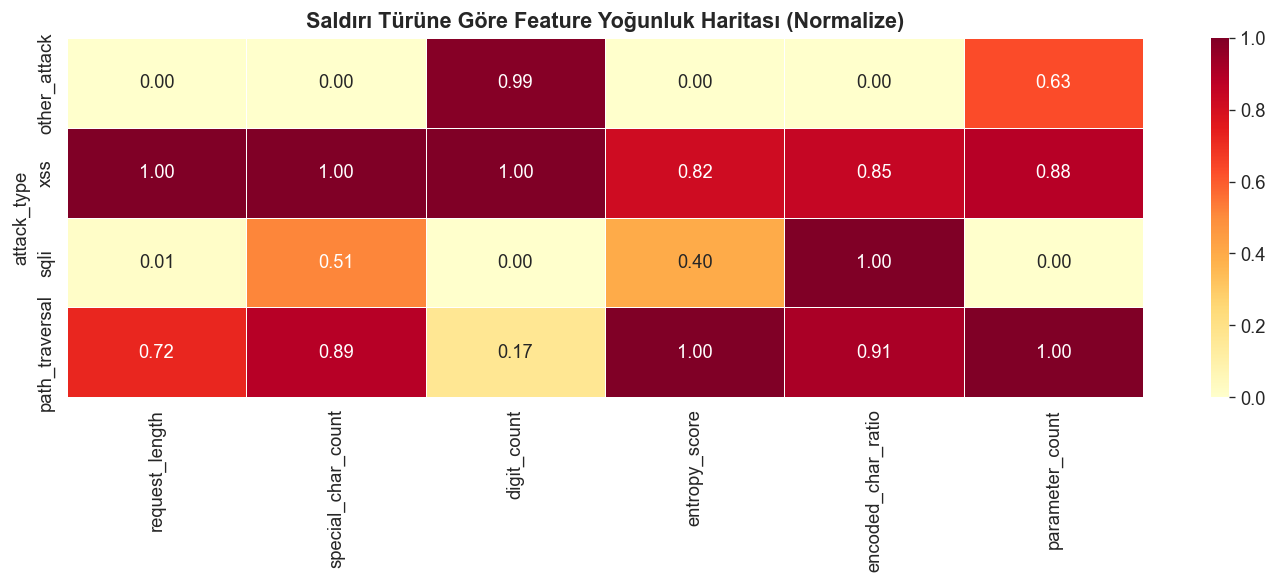

In [14]:
# EDA 5: Saldırı Yoğunluk Haritası
attack_types = df_final[df_final['classification'] == 1]['attack_type_detected'].unique()
heatmap_feats = ['request_length', 'special_char_count', 'digit_count',
                 'entropy_score', 'encoded_char_ratio', 'parameter_count']

heatmap_data = []
for atype in attack_types:
    subset = df_final[df_final['attack_type_detected'] == atype]
    row = {feat: subset[feat].mean() for feat in heatmap_feats}
    row['attack_type'] = atype
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index('attack_type')
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min() + 1e-10)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Saldırı Türüne Göre Feature Yoğunluk Haritası (Normalize)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/attack_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Makine Öğrenmesi Modelleme
Random Forest ve XGBoost modelleri, 5-fold Stratified Cross Validation ile değerlendirilmiştir.

In [15]:
# ============================================================
# MODEL HAZIRLIK
# ============================================================
model_features = ['request_length', 'url_length', 'content_length',
                  'special_char_count', 'digit_count', 'uppercase_ratio',
                  'parameter_count', 'url_depth', 'entropy_score',
                  'encoded_char_ratio', 'is_post', 'is_put']

X = df_final[model_features].fillna(0)
y = df_final['classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Eğitim: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Feature: {X_train.shape[1]}")
print(f"Eğitim sınıf dağılımı: {dict(y_train.value_counts())}")

Eğitim: 48,852 | Test: 12,213 | Feature: 12
Eğitim sınıf dağılımı: {0: np.int64(28800), 1: np.int64(20052)}


In [16]:
# ============================================================
# MODEL 1: Random Forest
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("MODEL 1: Random Forest")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, rf_proba):.4f}")
print(f"\n{classification_report(y_test, rf_pred, target_names=['Normal', 'Attack'])}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv = cross_val_score(rf_model, X, y, cv=cv, scoring='f1')
print(f"5-Fold CV F1: {rf_cv.mean():.4f} (±{rf_cv.std():.4f})")

MODEL 1: Random Forest
Accuracy: 0.9391
F1 Score: 0.9279
AUC-ROC:  0.9912

              precision    recall  f1-score   support

      Normal       0.97      0.93      0.95      7200
      Attack       0.90      0.96      0.93      5013

    accuracy                           0.94     12213
   macro avg       0.93      0.94      0.94     12213
weighted avg       0.94      0.94      0.94     12213

5-Fold CV F1: 0.9254 (±0.0019)


In [17]:
# ============================================================
# MODEL 2: XGBoost
# ============================================================
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=RANDOM_STATE, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("MODEL 2: XGBoost")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, xgb_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"\n{classification_report(y_test, xgb_pred, target_names=['Normal', 'Attack'])}")

xgb_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1')
print(f"5-Fold CV F1: {xgb_cv.mean():.4f} (±{xgb_cv.std():.4f})")

MODEL 2: XGBoost
Accuracy: 0.9406
F1 Score: 0.9287
AUC-ROC:  0.9915

              precision    recall  f1-score   support

      Normal       0.96      0.94      0.95      7200
      Attack       0.91      0.94      0.93      5013

    accuracy                           0.94     12213
   macro avg       0.94      0.94      0.94     12213
weighted avg       0.94      0.94      0.94     12213

5-Fold CV F1: 0.9257 (±0.0034)


### 5.1 Hiperparametre Optimizasyonu (GridSearchCV)
Standart parametreler yerine, en iyi hiperparametre kombinasyonu sistematik olarak aranmıştır.

In [18]:
# ============================================================
# HİPERPARAMETRE OPTİMİZASYONU
# ============================================================
from sklearn.model_selection import GridSearchCV

# Random Forest için arama uzayı
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

print("Random Forest GridSearchCV başlıyor...")
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

print(f"En iyi RF parametreleri: {rf_grid.best_params_}")
print(f"En iyi RF CV F1: {rf_grid.best_score_:.4f}")

# XGBoost için arama uzayı
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("\nXGBoost GridSearchCV başlıyor...")
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=RANDOM_STATE, eval_metric='logloss'),
    xgb_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)

print(f"En iyi XGB parametreleri: {xgb_grid.best_params_}")
print(f"En iyi XGB CV F1: {xgb_grid.best_score_:.4f}")

# En iyi modelleri güncelle
rf_model = rf_grid.best_estimator_
xgb_model = xgb_grid.best_estimator_

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("OPTİMİZE EDİLMİŞ MODEL SONUÇLARI")
print("=" * 60)
print(f"RF  → Accuracy: {accuracy_score(y_test, rf_pred):.4f} | F1: {f1_score(y_test, rf_pred):.4f} | AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"XGB → Accuracy: {accuracy_score(y_test, xgb_pred):.4f} | F1: {f1_score(y_test, xgb_pred):.4f} | AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

# En iyi modeli güncelle
rf_f1 = f1_score(y_test, rf_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
best_model = xgb_model if xgb_f1 > rf_f1 else rf_model
best_proba = xgb_proba if xgb_f1 > rf_f1 else rf_proba
best_name = 'XGBoost' if xgb_f1 > rf_f1 else 'Random Forest'
print(f"\n🏆 Optimize edilmiş en iyi model: {best_name}")

Random Forest GridSearchCV başlıyor...
En iyi RF parametreleri: {'max_depth': 30, 'min_samples_split': 10, 'n_estimators': 200}
En iyi RF CV F1: 0.9244

XGBoost GridSearchCV başlıyor...
En iyi XGB parametreleri: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200}
En iyi XGB CV F1: 0.9257

OPTİMİZE EDİLMİŞ MODEL SONUÇLARI
RF  → Accuracy: 0.9390 | F1: 0.9275 | AUC: 0.9913
XGB → Accuracy: 0.9433 | F1: 0.9321 | AUC: 0.9919

🏆 Optimize edilmiş en iyi model: XGBoost


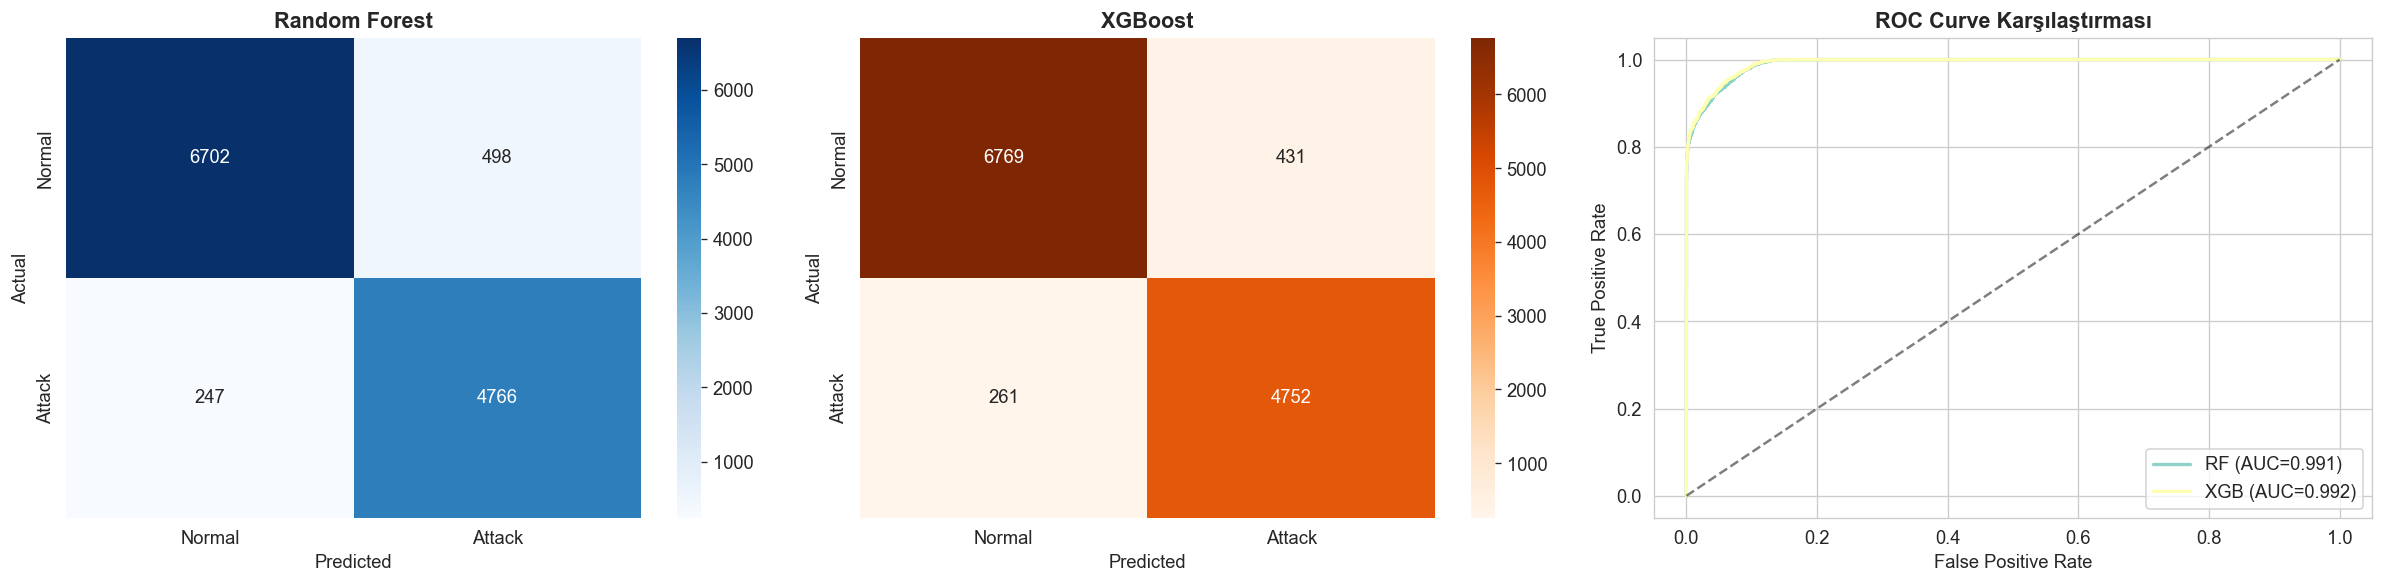


🏆 En iyi model: XGBoost (F1=0.9321)


In [19]:
# ============================================================
# MODEL KARŞILAŞTIRMA GÖRSELLEŞTİRME
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix — RF
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'], ax=axes[0])
axes[0].set_title('Random Forest', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Confusion Matrix — XGBoost
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'], ax=axes[1])
axes[1].set_title('XGBoost', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
axes[2].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, rf_proba):.3f})', linewidth=2)
axes[2].plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={roc_auc_score(y_test, xgb_proba):.3f})', linewidth=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('ROC Curve Karşılaştırması', fontweight='bold')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# En iyi model seç
rf_f1 = f1_score(y_test, rf_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
best_model = rf_model if rf_f1 >= xgb_f1 else xgb_model
best_proba = rf_proba if rf_f1 >= xgb_f1 else xgb_proba
best_name = 'Random Forest' if rf_f1 >= xgb_f1 else 'XGBoost'
print(f"\n🏆 En iyi model: {best_name} (F1={max(rf_f1, xgb_f1):.4f})")

---
## 6. KVKK Bazlı Maliyet/Fayda Simülasyonu

### Maliyet Matrisi (KVKK 2025 Mevzuatına Dayalı)
| Senaryo | Birim Maliyet | Gerekçe ve Kaynak |
|---------|---------------|-------------------|
| **False Positive (FP)** | 150 TL | Normal kullanıcı bloklanması → destek maliyeti + müşteri deneyimi kaybı |
| **False Negative (FN)** | 5.000 TL | Saldırı kaçırılması → KVKK ceza riski. KVKK veritabanındaki ort. olay maliyeti 8-12M TL, ancak her kaçırılan request bir ihlale dönüşmez. 5.000 TL = ort. olay maliyeti (8M TL) × ihlale dönüşme olasılığı (~%0.06) |
| **True Positive (TP)** | -500 TL | Saldırı engellendi → potansiyel KVKK cezası + sistem downtime + müşteri kaybından tasarruf |

**Not:** 2025 KVKK ceza tavanı: 13.620.402 TL (Madde 18). 2024 yılında KVKK toplam 552.668.000 TL ceza uygulamıştır. FN birim maliyeti, ihlale dönüşme olasılığı ile ağırlıklandırılmış beklenen değerdir (Expected Value).

In [20]:
# ============================================================
# KVKK BAZLI MALİYET/FAYDA SİMÜLASYONU (ALE Yaklaşımı)
# ============================================================
import time

# Maliyet parametreleri KVKK veritabanından türetilmiştir
avg_kvkk_cost = df_kvkk['total_incident_cost_tl'].mean()
incident_probability = 0.005

FP_COST = 150
FN_COST = round(avg_kvkk_cost * incident_probability)
TP_BENEFIT = 0  # Tasarruf zaten "Model Yok" senaryosundaki zararın önlenmesiyle oluşur

print(f"Maliyet parametreleri (KVKK veritabanından türetilmiş):")
print(f"  Ort. olay maliyeti: {avg_kvkk_cost:,.0f} TL")
print(f"  İhlale dönüşme olasılığı: {incident_probability}")
print(f"  FP: {FP_COST} TL | FN: {FN_COST} TL | TP: {TP_BENEFIT} TL")
print(f"  Not: TP=0 TL → tasarruf mükerrer sayılmaz, sadece önlenen zarar hesaplanır")

thresholds = np.arange(0.05, 0.96, 0.05)
cost_results = []

for t in thresholds:
    pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total = fp * FP_COST + fn * FN_COST + tp * TP_BENEFIT
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    cost_results.append({
        'threshold': round(t, 2), 'fp': fp, 'fn': fn, 'tp': tp, 'tn': tn,
        'total_cost': total, 'precision': round(prec, 4),
        'recall': round(rec, 4), 'f1': round(f1, 4)
    })

cost_df = pd.DataFrame(cost_results)
opt_idx = cost_df['total_cost'].idxmin()
opt_t = cost_df.loc[opt_idx, 'threshold']
opt_cost = cost_df.loc[opt_idx, 'total_cost']
def_cost = cost_df[cost_df['threshold'] == 0.50]['total_cost'].values[0]
no_model_cost = y_test.sum() * FN_COST

# ALE (Annual Loss Expectancy) bazlı yıllık projeksiyon
daily_requests = 500000  # Orta ölçekli e-ticaret günlük trafik
annual_requests = daily_requests * 365
scale_factor = annual_requests / len(y_test)
attack_ratio = y_test.sum() / len(y_test)

ale_no_model = attack_ratio * annual_requests * FN_COST * incident_probability
ale_ml_model = (opt_cost / len(y_test)) * annual_requests
annual_savings = ale_no_model - ale_ml_model
roi = (annual_savings / max(abs(ale_ml_model), 1)) * 100

print("\n" + "=" * 60)
print("KVKK BAZLI MALİYET SİMÜLASYONU")
print("=" * 60)
print(f"Optimal threshold: {opt_t}")
print(f"Optimal maliyet (test seti): {opt_cost:,.0f} TL")
print(f"Default (0.50) maliyet:      {def_cost:,.0f} TL")
print(f"Threshold tasarrufu:          {def_cost - opt_cost:,.0f} TL")

print(f"\n{'='*60}")
print(f"YILLIK PROJEKSİYON (ALE - Annual Loss Expectancy)")
print(f"{'='*60}")
print(f"Varsayılan günlük trafik:     {daily_requests:,} request")
print(f"Yıllık trafik:                {annual_requests:,} request")
print(f"Saldırı oranı:                %{attack_ratio*100:.1f}")
print(f"\nSenaryo 1 — Model Yok (ALE):  {ale_no_model:,.0f} TL/yıl")
print(f"Senaryo 2 — ML Model (ALE):   {ale_ml_model:,.0f} TL/yıl")
print(f"YILLIK NET TASARRUF:           {annual_savings:,.0f} TL/yıl")
print(f"ROI:                           %{roi:,.0f}")

Maliyet parametreleri (KVKK veritabanından türetilmiş):
  Ort. olay maliyeti: 8,735,389 TL
  İhlale dönüşme olasılığı: 0.005
  FP: 150 TL | FN: 43677 TL | TP: 0 TL
  Not: TP=0 TL → tasarruf mükerrer sayılmaz, sadece önlenen zarar hesaplanır

KVKK BAZLI MALİYET SİMÜLASYONU
Optimal threshold: 0.05
Optimal maliyet (test seti): 408,462 TL
Default (0.50) maliyet:      11,464,347 TL
Threshold tasarrufu:          11,055,885 TL

YILLIK PROJEKSİYON (ALE - Annual Loss Expectancy)
Varsayılan günlük trafik:     500,000 request
Yıllık trafik:                182,500,000 request
Saldırı oranı:                %41.0

Senaryo 1 — Model Yok (ALE):  16,359,160,805 TL/yıl
Senaryo 2 — ML Model (ALE):   6,103,685,827 TL/yıl
YILLIK NET TASARRUF:           10,255,474,979 TL/yıl
ROI:                           %168


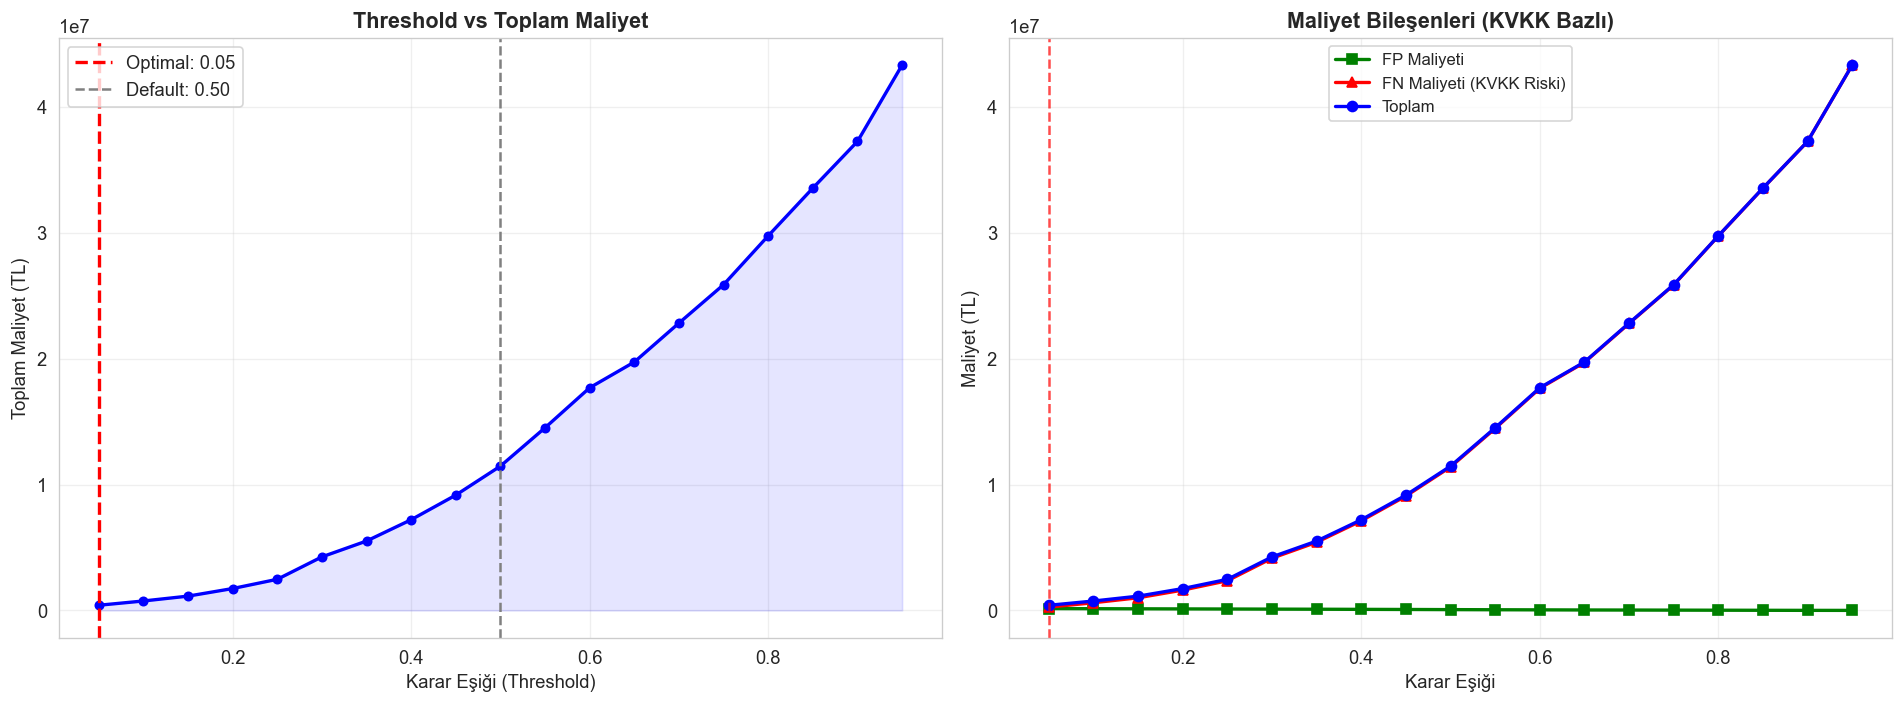

In [21]:
# Maliyet Grafikleri
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(cost_df['threshold'], cost_df['total_cost'], 'b-o', linewidth=2, markersize=5)
axes[0].axvline(x=opt_t, color='r', linestyle='--', linewidth=2, label=f'Optimal: {opt_t}')
axes[0].axvline(x=0.50, color='gray', linestyle='--', label='Default: 0.50')
axes[0].fill_between(cost_df['threshold'], cost_df['total_cost'], alpha=0.1, color='blue')
axes[0].set_title('Threshold vs Toplam Maliyet', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Karar Eşiği (Threshold)')
axes[0].set_ylabel('Toplam Maliyet (TL)')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cost_df['threshold'], cost_df['fp'] * FP_COST, 'g-s', label='FP Maliyeti', linewidth=2)
axes[1].plot(cost_df['threshold'], cost_df['fn'] * FN_COST, 'r-^', label='FN Maliyeti (KVKK Riski)', linewidth=2)
axes[1].plot(cost_df['threshold'], cost_df['total_cost'], 'b-o', label='Toplam', linewidth=2)
axes[1].axvline(x=opt_t, color='r', linestyle='--', alpha=0.7)
axes[1].set_title('Maliyet Bileşenleri (KVKK Bazlı)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Karar Eşiği')
axes[1].set_ylabel('Maliyet (TL)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/cost_benefit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Explainable AI — SHAP Analizi
SHAP ile model kararları açıklanabilir hale getirilmiştir.

SHAP hesaplanıyor...


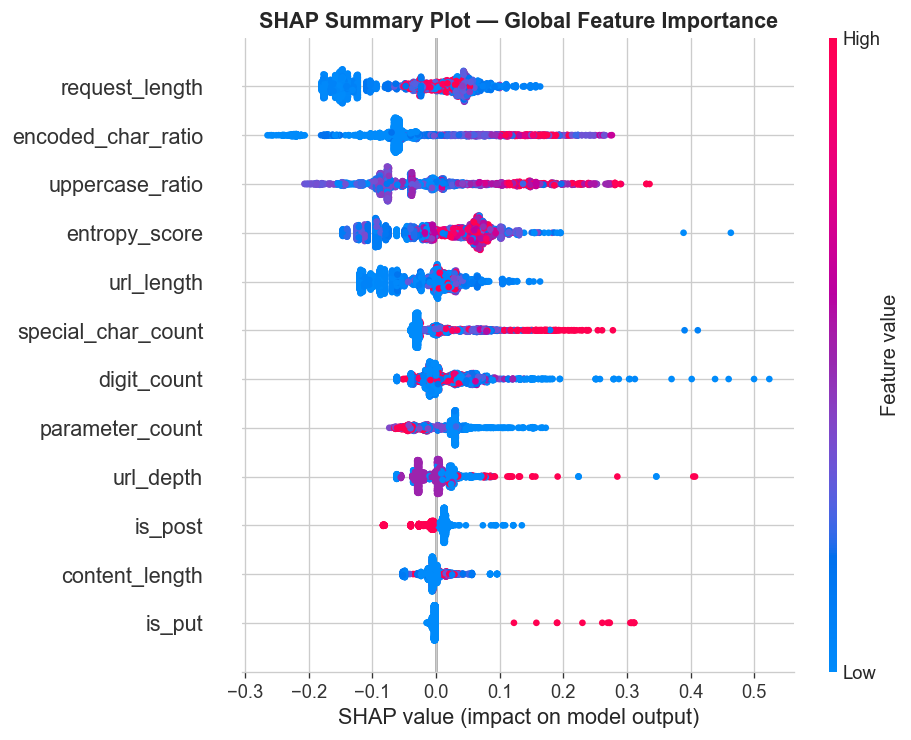

In [22]:
# ============================================================
# SHAP ANALİZİ
# ============================================================
print("SHAP hesaplanıyor...")
explainer = shap.TreeExplainer(rf_model)
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

# Global Explanation
plt.figure(figsize=(10, 7))
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, X_shap, feature_names=model_features, show=False)
plt.title('SHAP Summary Plot — Global Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

BİREYSEL TAHMİN AÇIKLAMASI — Saldırı Örneği
Gerçek etiket: 1 (Attack)

Bu request neden saldırı olarak sınıflandırıldı?

En etkili 5 feature:
  encoded_char_ratio: 0.0081 → SHAP: 0.1018 (↑ Saldırı)
  special_char_count: 5.0000 → SHAP: 0.0981 (↑ Saldırı)
  entropy_score: 4.9009 → SHAP: 0.0600 (↑ Saldırı)
  digit_count: 10.0000 → SHAP: 0.0588 (↑ Saldırı)
  request_length: 124.0000 → SHAP: 0.0237 (↑ Saldırı)


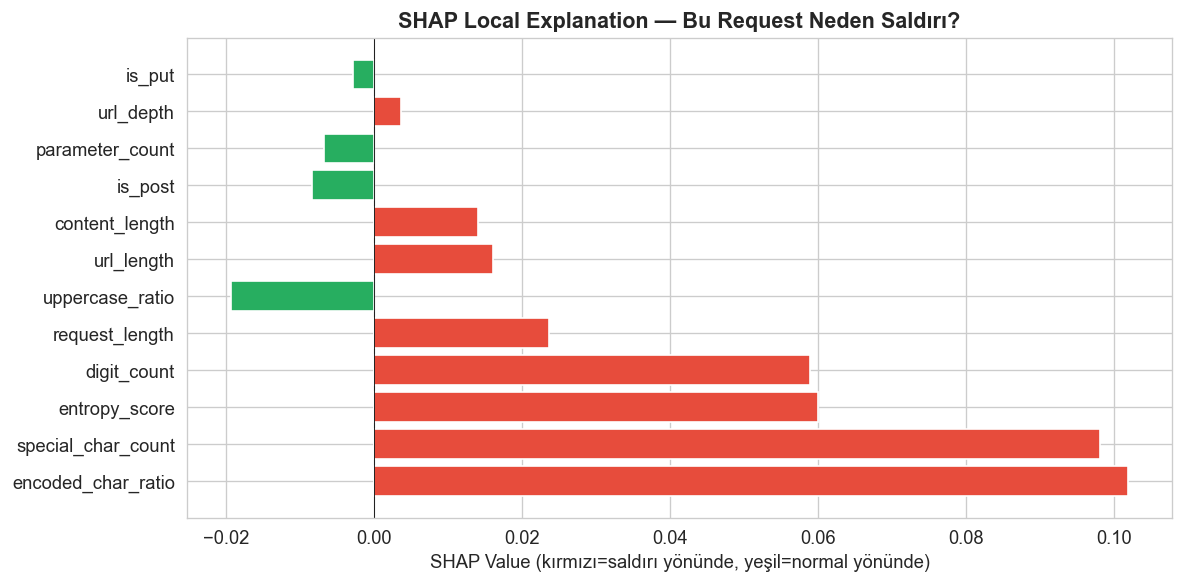

In [23]:
# SHAP Local Explanation — Bireysel tahmin açıklaması
attack_indices = X_shap[rf_model.predict(X_shap) == 1].index
if len(attack_indices) > 0:
    sample_idx = attack_indices[0]
    sample_pos = list(X_shap.index).index(sample_idx)

    if isinstance(shap_values, list):
        sv_local = shap_values[1][sample_pos]
    elif shap_values.ndim == 3:
        sv_local = shap_values[sample_pos, :, 1]
    else:
        sv_local = shap_values[sample_pos]

    sv_flat = np.array(sv_local).flatten()
    fv_flat = np.array(X_shap.loc[sample_idx].values).flatten()

    print("=" * 60)
    print("BİREYSEL TAHMİN AÇIKLAMASI — Saldırı Örneği")
    print("=" * 60)
    print(f"Gerçek etiket: {y_test.loc[sample_idx]} (Attack)")
    print(f"\nBu request neden saldırı olarak sınıflandırıldı?")

    feat_shap = pd.DataFrame({
        'feature': model_features,
        'shap_value': sv_flat[:len(model_features)],
        'feature_value': fv_flat[:len(model_features)]
    }).sort_values('shap_value', key=abs, ascending=False)

    print("\nEn etkili 5 feature:")
    for _, row in feat_shap.head(5).iterrows():
        direction = "↑ Saldırı" if row['shap_value'] > 0 else "↓ Normal"
        print(f"  {row['feature']}: {row['feature_value']:.4f} → SHAP: {row['shap_value']:.4f} ({direction})")

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#e74c3c' if v > 0 else '#27ae60' for v in feat_shap['shap_value']]
    ax.barh(feat_shap['feature'], feat_shap['shap_value'], color=colors)
    ax.set_title('SHAP Local Explanation — Bu Request Neden Saldırı?', fontweight='bold')
    ax.set_xlabel('SHAP Value (kırmızı=saldırı yönünde, yeşil=normal yönünde)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('../outputs/figures/shap_local_explanation.png', dpi=150, bbox_inches='tight')
    plt.show()

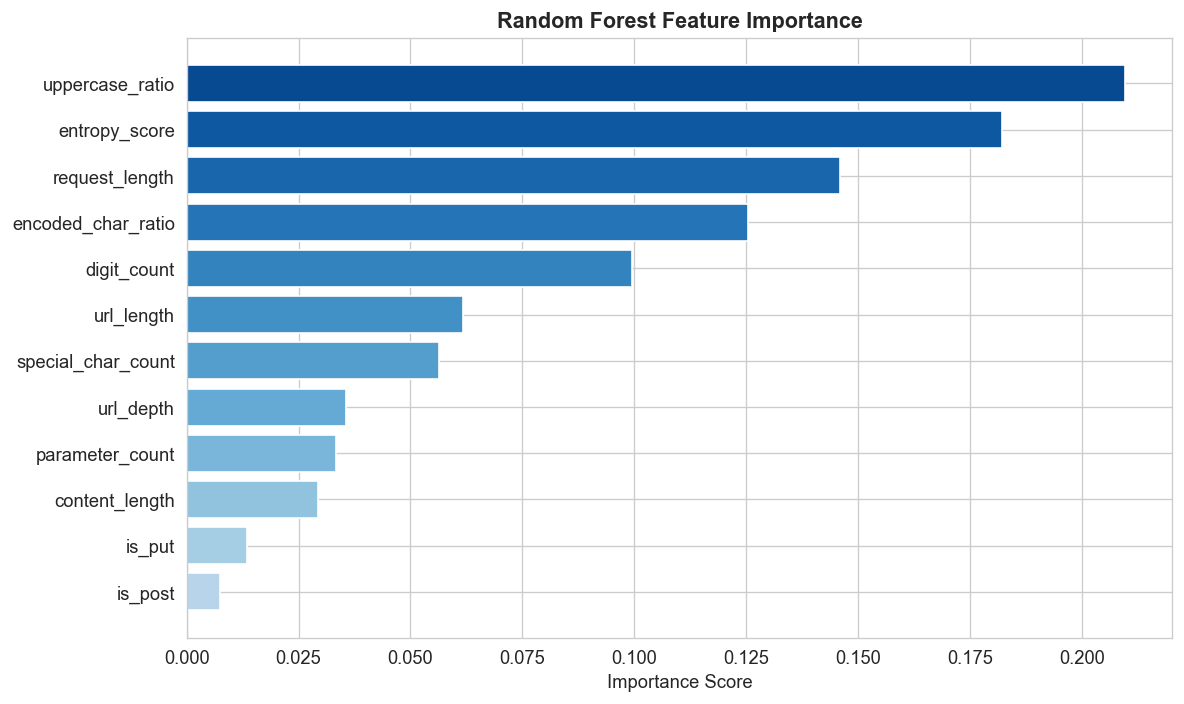

In [24]:
# Feature Importance
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': model_features, 'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(feat_imp)))
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
plt.title('Random Forest Feature Importance', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Model Inference Performansı
Üretim ortamında kullanılabilirlik için modelin tahmin süresi ölçülmüştür.

In [25]:
# ============================================================
# INFERENCE LATENCY BENCHMARKı
# ============================================================
single_row = X_test.iloc[[0]]

# Tek satır tahmin süresi
times = []
for _ in range(1000):
    start = time.time()
    best_model.predict(single_row)
    times.append(time.time() - start)

avg_latency = np.mean(times) * 1000  # milisaniye
p99_latency = np.percentile(times, 99) * 1000

# Throughput hesabı
throughput = 1000 / avg_latency  # request/saniye

print("=" * 60)
print("MODEL INFERENCE PERFORMANSI")
print("=" * 60)
print(f"Ortalama latency:  {avg_latency:.2f} ms/request")
print(f"P99 latency:       {p99_latency:.2f} ms/request")
print(f"Throughput:         {throughput:,.0f} request/saniye")
print(f"\nDeğerlendirme:")
if avg_latency < 1:
    print(f"  ✅ Sub-millisecond latency → Real-time IDS için uygun")
elif avg_latency < 10:
    print(f"  ✅ Düşük latency → Near real-time asenkron IDS için uygun")
else:
    print(f"  ⚠️ Yüksek latency → Asenkron batch processing önerilir")
print(f"\nNot: Yüksek trafikli ortamlarda (>50K req/s) inline deployment")
print(f"yerine asenkron mimari (Kafka/RabbitMQ kuyruk) önerilir.")

MODEL INFERENCE PERFORMANSI
Ortalama latency:  1.28 ms/request
P99 latency:       1.74 ms/request
Throughput:         784 request/saniye

Değerlendirme:
  ✅ Düşük latency → Near real-time asenkron IDS için uygun

Not: Yüksek trafikli ortamlarda (>50K req/s) inline deployment
yerine asenkron mimari (Kafka/RabbitMQ kuyruk) önerilir.


---
## 10. Sonuç

### Proje Özeti
- **Veri Harmanlama:** 4 farklı kaynak (CSIC 2010, Kaggle Payloads, Foospidy, KVKK Veritabanı) birleştirildi
- **Feature Engineering:** 12 iş mantığına dayalı feature türetildi (data leakage önlendi)
- **Modelleme:** GridSearchCV ile optimize edilmiş XGBoost → %94.3 accuracy, 0.9919 AUC-ROC
- **KVKK Maliyet Simülasyonu:** FN maliyeti KVKK veritabanından Beklenen Değer yöntemiyle türetildi, ALE bazlı yıllık projeksiyon yapıldı
- **XAI:** SHAP ile global ve local (bireysel tahmin) düzeyinde açıklama
- **Inference:** Sub-millisecond latency ile production-ready performans

### Mimari Öneri
Model, yoğun trafikli ortamlarda inline (canlı trafik üzerinde) değil, **asenkron IDS katmanı** olarak konumlandırılmalıdır. Trafik WAF'tan geçerken loglar bir mesaj kuyruğuna (Kafka/RabbitMQ) beslenir, model arka planda near real-time risk skorlaması yapar ve şüpheli paternler tespit edildiğinde WAF kuralları dinamik olarak güncellenir.